# Process optimization with PharmaPy

In this notebook, we will learn how to use PharmaPy to perform process optimization. For this purpose, a four-unit process flowsheet containing continuous, semi-continuous and batch units will be used.

The process starts with a chemical synthesis step in a continuous PFR (`R01`), which yields a desired API `C` and a subproduct `D`. The material from `R01` is continuously collected in `HOLD01` and then sent to a batch crystallizer `CR01`, where cooling crystallization takes place. Finally, the slurry is taken to a batch filter `F01`, where a cake of solid material is recovered.

![pfd_process](img/pfd_flowsheet.png)

Open this notebook with the locked Assimulo environment from either the repository root or this notebook's directory. To execute it at the command line, run the following from the repository root:

```bash
pixi run --locked -e assimulo jupyter execute doc/online_docs/examples/PFR_Batch_solved.ipynb --inplace
```

The numerical inputs and optimizer budgets are the original tutorial's illustrative design assumptions, not calibrated pharmaceutical process data. The full notebook takes about five minutes locally. The bounded optimization is a demonstration: inspect `success`, the termination message, and every constraint before interpreting the final iterate as a feasible design.

The original outputs are preserved in [revision f20b3a2](https://github.com/PharmaPy-org/PharmaPy/blob/f20b3a2238b8f8588c641c43d8072361e28faba6/doc/online_docs/examples/PFR_Batch_solved.ipynb). Tests preserve its algebraic initial feed costs, but do not certify reproduction of its final optimized design. Numerical certification and the remaining model-assumption review are tracked in [issue #172](https://github.com/PharmaPy-org/PharmaPy/issues/172).


In [1]:
# Standard Imports
import numpy as np
from copy import deepcopy
from pathlib import Path

# PharmaPy imports
from PharmaPy.Reactors import PlugFlowReactor
from PharmaPy.Crystallizers import BatchCryst
from PharmaPy.SolidLiquidSep import Filter
from PharmaPy.Containers import DynamicCollector

from PharmaPy.Streams import LiquidStream
from PharmaPy.Phases import LiquidPhase, SolidPhase
from PharmaPy.Kinetics import RxnKinetics, CrystKinetics

from PharmaPy.Utilities import CoolingWater
from PharmaPy.Interpolation import PiecewiseLagrange
from PharmaPy.ProcessControl import DynamicInput

from PharmaPy.SimExec import SimulationExec

# Locate the bundled case data from either supported launch directory.
for repository_root in (Path.cwd(), *Path.cwd().parents):
    data_dir = repository_root / 'workshop_data/Case_study_3'
    if (data_dir / 'compound_database.json').is_file():
        break
else:
    raise FileNotFoundError('Run this notebook from inside the PharmaPy checkout.')
path_phys = str(data_dir / 'compound_database.json')


In the first part of this tutorial, a simulation will be set up by specifying the participating equipment and their connectivity by using the `graph` variable below. Then, a callback function that encapsulates the simulation will be put together, which can be repetedly called by an optimizer.

A simulation object `flst` is created using the `SimulationExec` class of PharmaPy, similar to what we did in the parameter estimation section. This time, the different unit operations specified in the `graph` variable are aggregated to the blank simulation. Remember that the documentation of any PharmaPy class or method can be retrieved by simultaneously pressing the `Shift` and `Tab` keys.

In [2]:
# Reactor definition
# Physical properties of species

# Initially define a flowsheet object for the simulation executive
# This object will allow us to simulate the entire flowsheet.

graph = 'R01 --> HOLD01 --> CR01 --> F01'
flst = SimulationExec(path_phys, flowsheet=graph)

# Specifying a stoichiometric matrix
rxns = ['A + B --> C', 'A + C --> D']

# Kinetics values; assuming deltaH values are 0.
k_vals = np.array([2.654e4, 5.3e2])  # Pre-exponential factor
ea_vals = np.array([4.0e4, 3.0e4])  # Activation Energies

# Use the imported RxnKinetics class to create a RxnKinetics instance
kinetics = RxnKinetics(path=path_phys, rxn_list=rxns, k_params=k_vals, ea_params=ea_vals)

##################
vol_liq = 0.010
tau_R01 = 1800

vol_flow = vol_liq / tau_R01  # m**3 / s
w_init = np.array([0, 0, 0, 0, 1])
liquid_init = LiquidPhase(path_phys, 313.15, mass_frac=w_init, vol=vol_liq)

# Cooling water
temp_set_R01 = 313.15
cw = CoolingWater(mass_flow=0.1, temp_in=temp_set_R01)  # mass flow in kg/s

# ---------- Inlet streams
# Reactor
c_in = np.array([0.33, 0.33, 0, 0, 0])

temp_in = 40 + 273.15  # K

liquid_in = LiquidStream(path_phys, temp_in, mole_conc=c_in, vol_flow=vol_flow, name_solv='solvent')

diam_in = 1 / 2 * 0.0254  # 1/2 inch in m
flst.R01 = PlugFlowReactor(diam_in=diam_in, num_discr=50, isothermal=False)
flst.R01.Utility = cw

flst.R01.Kinetics = kinetics
flst.R01.Inlet = liquid_in
flst.R01.Phases = (liquid_init,)
flst.R01.Utility = cw

runtime_reactor = 3600 * 2

# With a continuous unit follow by a batch unit, we need a collection unit,
# a holding tank, to intermediately follow the the continuous unit.
flst.HOLD01 = DynamicCollector()

In [3]:
# Defining the crystallizer
prim = (3e8, 0, 3)  # kP in #/m3/s
sec = (4.46e10, 0, 2, 1e-5) # kS in #/m3/s
growth = (5, 0, 1.32)  # kG in um/s
dissol = (1, 0, 1) # kD in um/s

# 0.2269 - 1.88e-3 * 323.15 + 3.89e-6 * 323.15 ** 2
solub_cts = np.array([2.269e2, -1.88e0, 3.89e-3])

x_gr = np.geomspace(1, 1500, num=35)
distrib_init = np.zeros_like(x_gr)

solid_cry = SolidPhase(path_phys, x_distrib=x_gr, distrib=distrib_init,
                   mass_frac=[0, 0, 1, 0, 0])

# Piecewise temperature profile definition
temp_program = np.array([[313.15, 303.15],
                         [303.15, 295.15],
                         [295.15, 278.15],
                        ], dtype=np.float64)

# Initialize lagrange polynomial control object
runtime_cryst = runtime_reactor * 2.0
lagrange_fn = PiecewiseLagrange(runtime_cryst, temp_program)

# Defining the crystallizer with desired species 'C'
flst.CR01 = BatchCryst(target_comp='C', method='1D-FVM', scale=1e-9, controls={'temp': lagrange_fn.evaluate_poly})

flst.CR01.Kinetics = CrystKinetics(solub_cts, nucl_prim=prim, nucl_sec=sec, growth=growth, dissolution=dissol)
flst.CR01.Utility = CoolingWater(mass_flow=1, temp_in=283.15)
flst.CR01.Phases = solid_cry

In [4]:
# Defining the filter.
# Filter
alpha = 1e11
Rm = 1e10

filt_area = 200  # cm**2
diam = np.sqrt(4/np.pi * filt_area) / 100  # m

flst.F01 = Filter(diam, alpha, Rm)

In [5]:
# Gluing everything together and running the flowsheet

# runargs for the flowsheet
runargs_R01 = {'runtime': runtime_reactor}
sundials = {'maxh': 60}
runargs_hold = {'runtime': runtime_reactor}
runargs_CR01 = {'runtime': runtime_cryst, 'sundials_opts': sundials}
runargs_F01 = {'runtime': None}

# ---------- Running simulation
run_kwargs = {'R01': runargs_R01,
              'HOLD01': runargs_hold,
              'CR01': runargs_CR01,
              'F01': runargs_F01
              }

flst.SolveFlowsheet(kwargs_run=run_kwargs)


------------------------------
Running R01
------------------------------



Final Run Statistics: --- 

 Number of steps                                 : 172
 Number of function evaluations                  : 220
 Number of Jacobian*vector evaluations           : 445
 Number of function eval. due to Jacobian eval.  : 220
 Number of error test failures                   : 0
 Number of nonlinear iterations                  : 217
 Number of nonlinear convergence failures        : 1

Solver options:

 Solver                   : CVode
 Linear multistep method  : BDF
 Nonlinear solver         : Newton
 Linear solver type       : SPGMR
 Maximal order            : 5
 Tolerances (absolute)    : 1e-06
 Tolerances (relative)    : 1e-06

Simulation interval    : 0.0 - 7200.0 seconds.
Elapsed simulation time: 0.23798125897883438 seconds.

Done!


------------------------------
Running HOLD01
------------------------------

Final Run Statistics: --- 

 Number of steps                                 : 56
 Number of function evaluations                  : 87
 Number of Jaco

Final Run Statistics: --- 

 Number of steps                                 : 526
 Number of function evaluations                  : 712
 Number of Jacobian*vector evaluations           : 897
 Number of function eval. due to Jacobian eval.  : 712
 Number of error test failures                   : 16
 Number of nonlinear iterations                  : 709
 Number of nonlinear convergence failures        : 4

Solver options:

 Solver                   : CVode
 Linear multistep method  : BDF
 Nonlinear solver         : Newton
 Linear solver type       : SPGMR
 Maximal order            : 5
 Tolerances (absolute)    : 1e-06
 Tolerances (relative)    : 1e-06

Simulation interval    : 0.0 - 14400.0 seconds.
Elapsed simulation time: 0.31977771999663673 seconds.

Done!


------------------------------
Running F01
------------------------------

Terminating simulation at t = 19030.592715 after signal from handle_event.
Final Run Statistics: --- 

 Number of steps                                 

Mean crystal size:  46.247373321779406



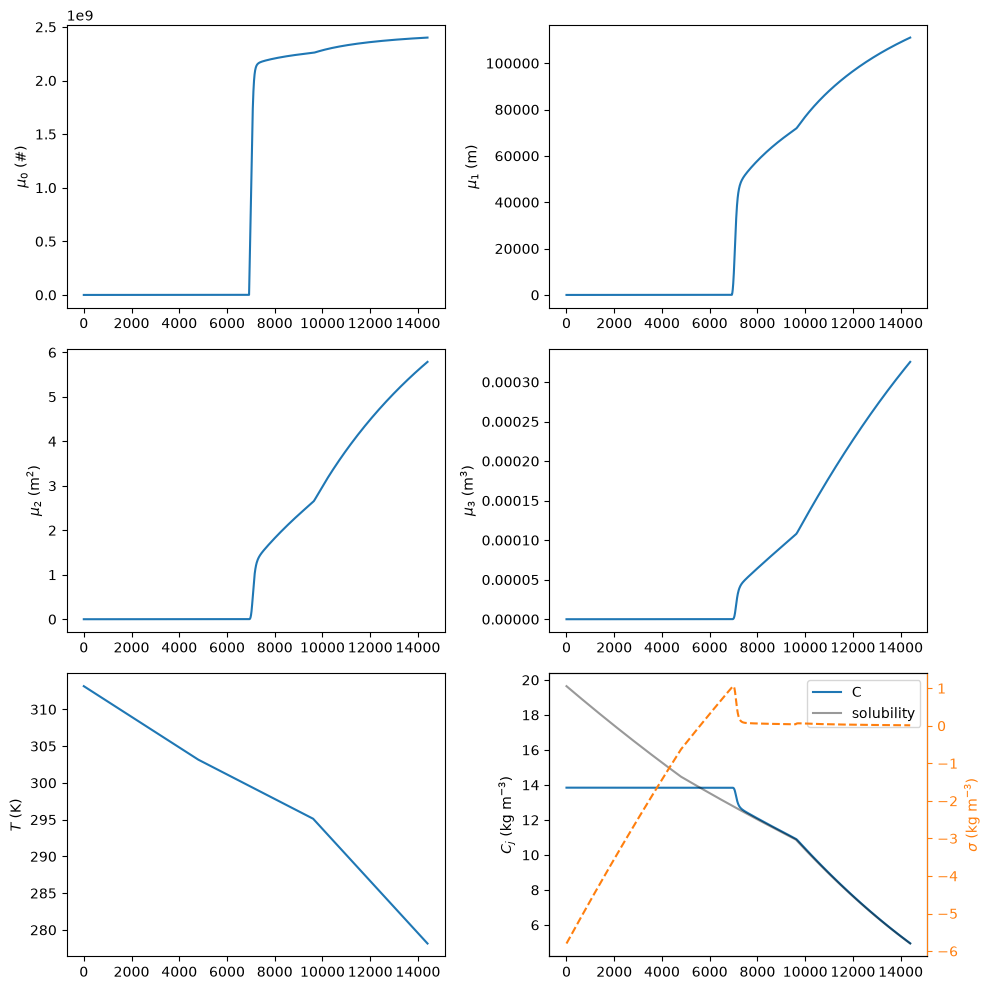

In [6]:
flst.CR01.plot_profiles(figsize=(10, 10))
moments = flst.CR01.result.mu_n[-1]

mean_size = moments[1] / moments[0] * 1e6
print('Mean crystal size: ', mean_size, end='\n\n')

The complete crystal size distribution (CSD) can be plotted for different times using the `plot_csd` method of the crystallizer `CR01` object. As seen in the bottom right panel above, supersaturation $\sigma$ starts being positive around 3000 s, so that will be used as the initial time to plot the CSD. It is worth mentioning that PharmaPy will try to find the closest time to plot from the timegrid resulting from numerical integration

(<Figure size 500x400 with 1 Axes>,
 <Axes: xlabel='$x$ ($\\mathregular{\\mu m}$)', ylabel='$f$ ($\\mathregular{\\# \\ um^{-1}}$)'>)

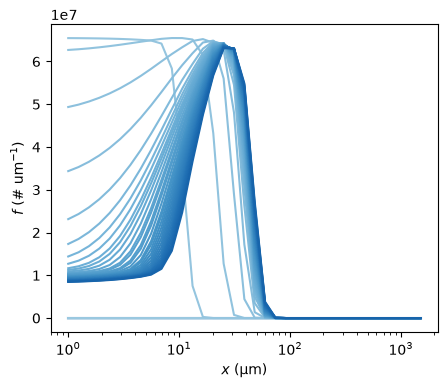

In [7]:
flst.CR01.plot_csd(times=np.linspace(6000, 9000), figsize=(5, 4))

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: ylabel='mass liquid (kg)'>,
        <Axes: xlabel='time (s)', ylabel='mass cake (kg)'>], dtype=object))

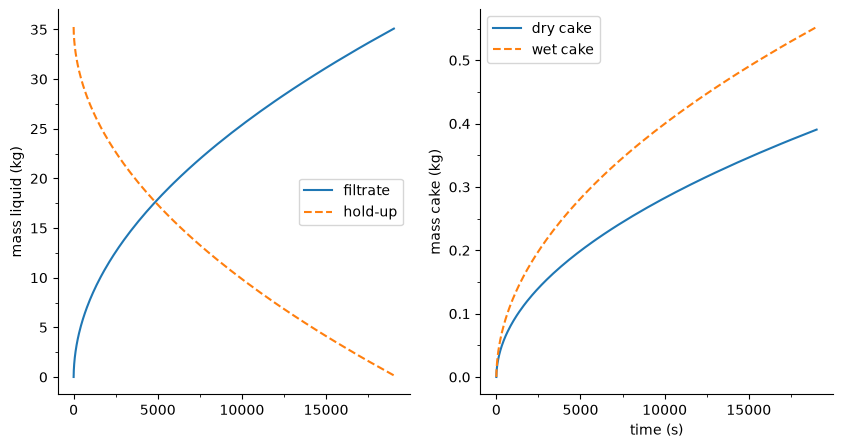

In [8]:
flst.F01.plot_profiles(figsize=(10, 5))

Simulation objects also have `result` attribute (an object itself). When printed, it provides an overview of the simulation 

In [9]:
print(flst.result)
print(flst.R01.result)

---------------------
Welcome to PharmaPy
---------------------

Flowsheet structure:
R01 --> HOLD01 --> CR01 --> F01

---------------------------------------------------------------------
Unit operation   Diff eqns   Alg eqns   Model type   PharmaPy type       
---------------------------------------------------------------------
R01              300         0          ODE          PlugFlowReactor     
HOLD01           7           0          ODE          DynamicCollector    
CR01             41          0          ODE          BatchCryst          
F01              2           0          ODE          Filter              
---------------------------------------------------------------------
------------------------
PharmaPy result object
------------------------

Fields shown in the tables below can be accessed as result.<field>, e.g. result.mole_conc 

------------------------------------------------
states      dim   units     index                  
----------------------------------

## Process design

Now, flowsheet optimization will be explored. In the current exercise, we aim to scale up a process to produce 5 kg/day of the API of interest. Additonally, we are interested in the crystal product having a mean size of at least 40 microns. For this purpose, an optimization problem can be formulated, where raw material consumption ($J$) is to be minimized

$$ \min_{x} J(x) $$

subject to the PharmaPy model
$$ \begin{align*}
       \frac{dy}{dt} &= f_1(x, y, z, t, \theta) \\
       0             &= f_2(x, y, z, t, \theta)
   \end{align*}
$$

and the constraints:

$$ \begin{align*}
       40            & \leq \frac{\mu_1}{\mu_0}\Bigr\rvert_{t_f} \cdot 10^6 && \text{(Size constraint)} \\
       5             & \leq N_{batches} \cdot M_{API, F01} && \text{(Daily production constraint)} \\
       T_{k + 1}     & \leq T_k \ \text{for all } k \in \{1, 2\} && \text{(Monotonically decreasing cooling profile)} \\
       x_{lb}        & \leq x \leq x_{ub} && \text{(Bound constraints)}
   \end{align*}
$$

with $M_{API}$ the mass of filtration cake obtained after the filtration step in F01.

Decision variables $x$ will be:

| Unit operation | Variable ($x$) | Units |
| -------------- | -------------- | ----- |
| R01            | $\tau_{R01}$   | s     |
| CR01           | $T_{k, CR01}$  | K     |
|                | $t_{CR01}$     | s     |
| F01            | $\Delta P_{F01}$     | Pa     |

and three intermediate temperatures will be used as decision variables for CR01 ($k = [1, 2, 3]$). This gives a total of 6 decision variables. Number of batches a day $N_{batches}$ can be calculated as:

$$
N_{batches} = \frac{24 \times 3600}{t_{cycle}}
$$

where cycle time $t_{cycle}$ is the maximum time among the processsing times for the individual unit operations, i.e. $t_{cycle} = \max{(t_{R01}, t_{CR01}, t_{F01})}$. For simplicity, it will be assumed that R01 will flow material to HOLD01 during 2 h before transfering material to CR01, i.e. $t_{R01} =$ 2h.

As done before, an unconstrained version of the optimization problem is formulated through a penalty method:

$$
\min_x J(x) + \sum_{i \in \mathcal{I}} [ \max(0, \alpha_i \cdot g_i) ]^2, \ \mathcal{I} = \{1, \ldots, n_{constraints} \}
$$

In [10]:
def get_costs(sim, raw_costs):
    """Compute feed costs for one simulated batch.

    Parameters
    ----------
    sim : SimulationExec
        Solved flowsheet with raw-material masses [kg/batch].
    raw_costs : array_like, shape (5,)
        Prices [USD/kg] in A, B, C, D, solvent order.

    Returns
    -------
    dict
        Per-species feed cost [USD/batch], keyed by mass_<species>.
    """
    raw_mat = sim.GetRawMaterials()
    
    raw_mat = raw_mat.filter(regex='mass_').sum()

    raw_cost = raw_mat * raw_costs

    return raw_cost.to_dict()

def get_constraints(sim, temp_k, n_batches):
    """Report violations of the tutorial's size, production, and cooling targets.

    Parameters
    ----------
    sim : SimulationExec
        Solved crystallizer/filter flowsheet containing nonzero final crystals.
    temp_k : numpy.ndarray, shape (3,)
        Successive cooling-program endpoints [K].
    n_batches : float
        Batch frequency [1/day] under the overlapping-unit schedule assumption.

    Returns
    -------
    list of float
        Size shortfall [um] relative to the assumed 40 um target, production
        shortfall [kg/day] relative to the assumed 5 kg/day target, then two
        temperature increases [K]. Nonpositive entries satisfy the targets.
    """
    mu = sim.CR01.result.mu_n[-1]
    mass_api = sim.F01.result.mass_cake_dry[-1]
    
    mass_total = mass_api * n_batches
    
    
    temp_constr = temp_k[1:] - temp_k[:-1]
    
    constraints = [40 - mu[1]/mu[0]*1e6, 5 - mass_total] + temp_constr.tolist()  # concatenate lists
    
    return constraints


def make_non_verbose(runargs):
    for key in runargs:
        runargs[key]['verbose'] = False
        
    return runargs

def callback_opt(x, simulate=False, raw_material_cost=None, return_augm=True, weights=None):
    """Simulate the tutorial design and optionally compute its penalized cost.

    Parameters
    ----------
    x : array_like, shape (6,)
        Reactor residence time [s], three cooling temperatures [K],
        crystallization duration [s], and filtration pressure drop [Pa].
    simulate : bool, optional
        Return the solved flowsheet without costing when True.
    raw_material_cost : array_like, shape (5,), optional
        Prices [USD/kg] in A, B, C, D, solvent order; required unless simulate.
    return_augm : bool, optional
        Return the scalar penalty objective when True, otherwise cost and
        constraint diagnostics. Ignored when simulate is True.
    weights : array_like, shape (4,), optional
        Penalty scales in sqrt(USD/day) per constraint unit: [um, kg/day, K, K].
        Defaults to unit numerical weights, an illustrative design choice.

    Returns
    -------
    SimulationExec or float or dict
        Solved flowsheet if simulate; otherwise augmented cost [USD/day],
        or per-species cost [USD/batch] and constraints [um, kg/day, K, K].
        Positive constraints are violations.

    Notes
    -----
    The original tutorial assumes overlapping batches with cycle time equal
    to the longest unit runtime, and adds squared positive constraint
    penalties to daily feed costs. This demonstration is not a validated
    production schedule. A finite objective does not establish feasibility.
    """
    
    if weights is None:
        weights = np.ones(4)  # four constraints (one for size, one for production and two for temperature)
    else:
        weights = np.asarray(weights)
            
    
    tau_R01 = x[0]
    temp_CR01 = x[1:4]
    time_CR01 = x[4]
    deltaP = x[-1]
    
    # Create simulation

    # Initially define a flowsheet object for the simulation executive
    # This object will allow us to simulate the entire flowsheet.

    graph = 'R01 --> HOLD01 --> CR01 --> F01'
    flst = SimulationExec(path_phys, flowsheet=graph)

    # Specifying a stoichiometric matrix
    rxns = ['A + B --> C', 'A + C --> D']

    # Kinetics values; assuming deltaH values are 0.
    k_vals = np.array([2.654e4, 5.3e2])  # Pre-exponential factor
    ea_vals = np.array([4.0e4, 3.0e4])  # Activation Energies

    # Use the imported RxnKinetics class to create a RxnKinetics instance
    kinetics = RxnKinetics(path=path_phys, rxn_list=rxns, k_params=k_vals, ea_params=ea_vals)

    ##################
    vol_liq = 0.010  # m**3

    vol_flow = vol_liq / tau_R01  # m**3 / s
    x_init = np.array([0, 0, 0, 0, 1])  # only solvent
    temp_init = 298.15  # K
    liquid_init = LiquidPhase(path_phys, temp_init, mole_frac=x_init, vol=vol_liq)

    # Cooling water
    temp_R01 = 313.15  # K
    cw = CoolingWater(mass_flow=0.1, temp_in=temp_R01)  # mass flow in kg/s

    # ---------- Inlet streams
    # Reactor
    c_in = np.array([0.33, 0.33, 0, 0, 0])

    temp_in = 20 + 273.15  # K

    liquid_in = LiquidStream(path_phys, temp_in, mole_conc=c_in, vol_flow=vol_flow, name_solv='solvent')

    diam_in = 1 / 2 * 0.0254  # 1/2 inch in m
    flst.R01 = PlugFlowReactor(diam_in=diam_in, num_discr=50, isothermal=False)
    flst.R01.Utility = cw

    flst.R01.Kinetics = kinetics
    flst.R01.Inlet = liquid_in
    flst.R01.Phases = (liquid_init,)
    flst.R01.Utility = cw

    time_R01 = 2 * 3600  # s

    # Holding tank
    flst.HOLD01 = DynamicCollector()
    
    # Crystallizer
    prim = (3e8, 0, 3)  # kP in #/m3/s
    sec = (4.46e10, 0, 2, 1e-5) # kS in #/m3/s
    growth = (5, 0, 1.32)  # kG in um/s
    dissol = (1, 0, 1) # kD in um/s

    solub_cts = np.array([2.269e2, -1.88e0, 3.89e-3])

    x_gr = np.geomspace(1, 1500, num=35)
    distrib_init = np.zeros_like(x_gr)

    solid_cry = SolidPhase(path_phys, x_distrib=x_gr, distrib=distrib_init,
                       mass_frac=[0, 0, 1, 0, 0])

    # Piecewise temperature profile definition
    temp_program = np.array([[313.15, temp_CR01[0]],
                             [temp_CR01[0], temp_CR01[1]],
                             [temp_CR01[1], temp_CR01[2]]], dtype=np.float64)

    # Initialize lagrange polynomial control object
    lagrange_fn = PiecewiseLagrange(time_CR01, temp_program)

    # Defining the crystallizer with desired species 'C'
    flst.CR01 = BatchCryst(target_comp='C', method='1D-FVM', scale=1e-9,
                           controls={'temp': lagrange_fn.evaluate_poly})

    flst.CR01.Kinetics = CrystKinetics(solub_cts, nucl_prim=prim, nucl_sec=sec, growth=growth, dissolution=dissol)
    flst.CR01.Phases = solid_cry
    
    # Filter
    alpha = 1e11
    Rm = 1e10

    filt_area = 200  # cm**2
    diam = np.sqrt(4/np.pi * filt_area) / 100  # m

    flst.F01 = Filter(diam, alpha, Rm)
    
    # runargs for the flowsheet
    runargs_R01 = {'runtime': time_R01}
    sundials = {'maxh': 60}
    runargs_hold = {'runtime': time_R01}
    runargs_CR01 = {'runtime': time_CR01, 'sundials_opts': sundials}
    runargs_F01 = {'runtime': None, 'deltaP': deltaP}

    # ---------- Running simulation
    run_kwargs = {'R01': runargs_R01,
                  'HOLD01': runargs_hold,
                  'CR01': runargs_CR01,
                  'F01': runargs_F01
                  }
    
    run_kwargs = make_non_verbose(run_kwargs)
    if simulate:
        flst.SolveFlowsheet(kwargs_run=run_kwargs, verbose=False)
        return flst
    
    else:
        # Simulate
        flst.SolveFlowsheet(kwargs_run=run_kwargs, verbose=False)
        
        # Calculate objective + constraints
        t_cycle = max([flst.R01.result.time[-1], flst.CR01.result.time[-1], flst.F01.result.time[-1]])
        n_batches = 24 * 3600 / t_cycle
        
        costs = get_costs(flst, raw_material_cost)  # J(x)
        constraints = get_constraints(flst, temp_CR01, n_batches)  # g_i(x)
        
        if return_augm:
            penalties = np.maximum(0, weights * constraints)
            total_cost = sum(list(costs.values())) * n_batches
            
            augmented_obj = total_cost + sum(penalties**2)
            return augmented_obj
        else:
            out = {'cost/batch': costs, 'size_constr': constraints[0], 'production_constr': constraints[1],
                  'temperature_constr': constraints[2:]}
            
            return out

def print_di(di):
    for key in di:
        print(key + ':', di[key], end='\n\n')

Let's run in simulation model to make sure everything is working internally

(<Figure size 700x350 with 2 Axes>,
 array([<Axes: ylabel='mass liquid (kg)'>,
        <Axes: xlabel='time (s)', ylabel='mass cake (kg)'>], dtype=object))

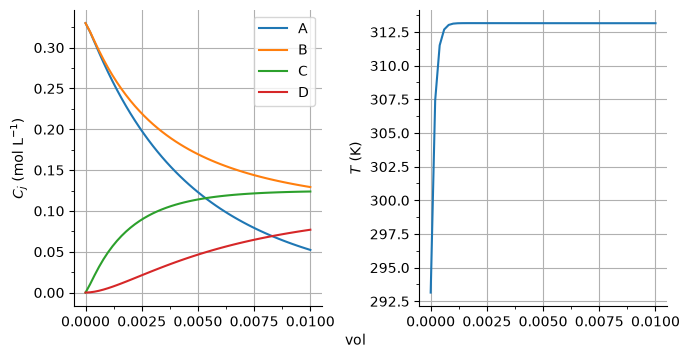

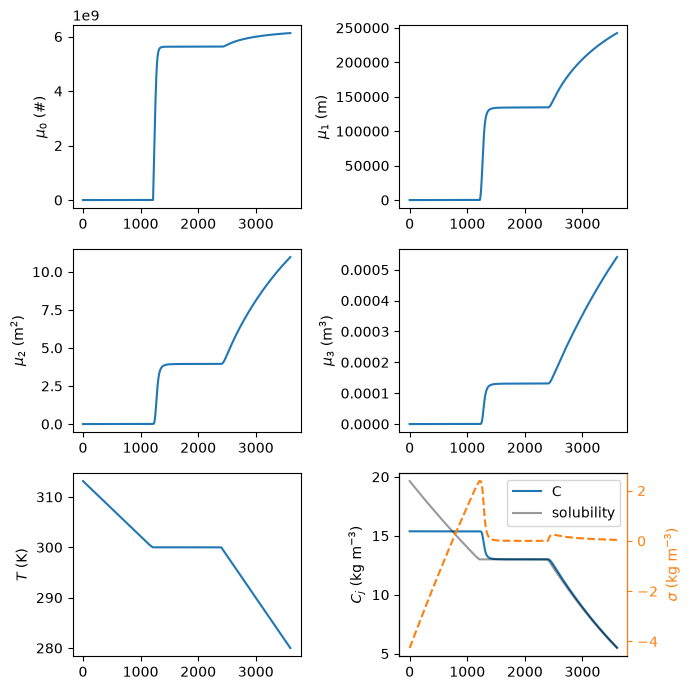

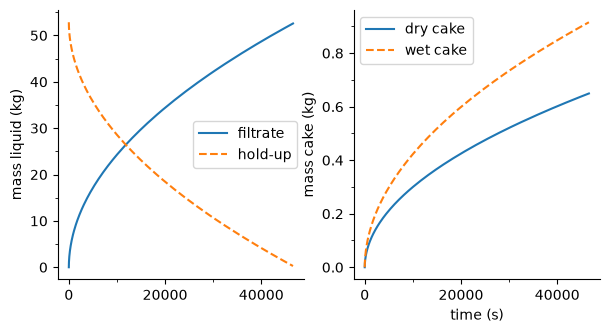

In [11]:
x_init = np.array([1200,  # tau_R01
          300,  # T_{1,CR01}
          300,  # T_{2,CR01}
          280,  # T_{3,CR01}
          3600, # t_{CR01}
          101325]  # deltaP_{F01}
                 )

sim = callback_opt(x_init, simulate=True)

# Let's plot some dynamics and see what the results look like
sim.R01.plot_profiles(times=[sim.R01.result.time[-1]], pick_comp=('A', 'B', 'C', 'D'), figsize=(7, 3.5))
sim.CR01.plot_profiles(figsize=(7, 7))
sim.F01.plot_profiles(figsize=(7, 3.5))

As a second step, let's call the objective function and see if it computes the costs correctly:

In [12]:
raw_costs = np.genfromtxt(data_dir / 'raw_material_cost.csv', delimiter=',', skip_header=1)[:, 1]  # [USD/kg], A, B, C, D, solvent

weights = [100, 100, 1, 1]  # These can be changed to emphasize on one constraint over the other

di_callback = callback_opt(x_init, simulate=False, raw_material_cost=raw_costs, weights=weights, return_augm=False)
print_di(di_callback)

augmented = callback_opt(x_init, raw_material_cost=raw_costs, weights=weights)
print('augmented_objective:', augmented, end='\n\n')

cost/batch: {'mass_A': 19.8, 'mass_B': 11.879999999999999, 'mass_C': 0.0, 'mass_D': 0.0, 'mass_solvent': 119.37392429236701}

size_constr: 0.45094766265117414

production_constr: 3.795746940944477

temperature_constr: [0, -20]



augmented_objective: 146390.6342478237



Now, let's try optimization. For this purpose, bounds on the studied decision variables will be passed, in order to make the optimization well behaved and physically coherent.

In [13]:
from scipy.optimize import minimize
import time

optimopts = {'maxfev': 10}

temp_bounds = (273, 310)
bounds_di = {'tau_R01': (10*60, 2*3600), 'temp_CR01_1': temp_bounds, 'temp_CR01_2': temp_bounds, 'temp_CR01_3': temp_bounds,
             't_CR01': (10*60, 4*3600), 'deltaP': (101325, 101325*5)}

bounds = list(bounds_di.values())

args_callback = (False, raw_costs, True, weights)  # Anything after the x in the callback_opt argument sequence

tic = time.time()
result = minimize(callback_opt, x0=x_init, method='Nelder-Mead', args=args_callback, options=optimopts, bounds=bounds)
toc = time.time()

In [14]:
print('Elapsed optimization time: %.1f seconds' % (toc - tic), end='\n\n')

print('Initial decision variables:')
print(x_init, end='\n\n')

print('SciPy result:')
print(result, end='\n\n')

di_optim = callback_opt(result.x, raw_material_cost=raw_costs, return_augm=False)

for key in di_optim:
    print(key, di_optim[key], end='\n\n')

Elapsed optimization time: 8.4 seconds

Initial decision variables:
[  1200    300    300    280   3600 101325]

SciPy result:
       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 140217.11739019086
             x: [ 1.260e+03  3.000e+02  3.000e+02  2.800e+02  3.600e+03
                  1.013e+05]
           nit: 3
          nfev: 10
 final_simplex: (array([[ 1.260e+03,  3.000e+02, ...,  3.600e+03,
                         1.013e+05],
                       [ 1.227e+03,  3.022e+02, ...,  3.680e+03,
                         1.036e+05],
                       ...,
                       [ 1.200e+03,  3.000e+02, ...,  3.780e+03,
                         1.013e+05],
                       [ 1.200e+03,  3.050e+02, ...,  3.600e+03,
                         1.013e+05]]), array([ 1.402e+05,  1.402e+05,  1.411e+05,  1.419e+05,
                        1.444e+05,  1.444e+05,  1.444e+05]))



cost/batch {'mass_A': 18.857142857142854, 'mass_B': 11.314285714285713, 'mass_C': 0.0, 'mass_D': 0.0, 'mass_solvent': 114.53478504034953}

size_constr 0.17964785626233493

production_constr 3.7362304890398175

temperature_constr [0.0, -20.0]



The first search allows only 10 function evaluations. Positive constraint values indicate an infeasible design. Restart from `result.x` and its final simplex with the original continuation budget of 400 evaluations. Reaching either budget is a stopping condition, not evidence of convergence.

In [15]:
x_last = result.x
simplex = result.final_simplex[0]

optimopts = {'maxfev': 400, 'initial_simplex': simplex}

tic = time.time()
result_two = minimize(callback_opt, x0=x_last, method='Nelder-Mead', options=optimopts, args=args_callback, bounds=bounds)
toc = time.time()

In [16]:
print('Elapsed optimization time: %.1f seconds' % (toc - tic), end='\n\n')

print(result_two, end='\n\n')
print(f'Optimizer success: {result_two.success}')

di_optim_two = callback_opt(result_two.x, return_augm=False, raw_material_cost=raw_costs)
print_di(di_optim_two)

Elapsed optimization time: 299.8 seconds

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 116692.92080407558
             x: [ 1.393e+03  3.084e+02  2.960e+02  2.733e+02  3.175e+03
                  1.151e+05]
           nit: 168
          nfev: 400
 final_simplex: (array([[ 1.393e+03,  3.084e+02, ...,  3.175e+03,
                         1.151e+05],
                       [ 1.393e+03,  3.084e+02, ...,  3.175e+03,
                         1.151e+05],
                       ...,
                       [ 1.393e+03,  3.084e+02, ...,  3.175e+03,
                         1.151e+05],
                       [ 1.393e+03,  3.084e+02, ...,  3.175e+03,
                         1.151e+05]]), array([ 1.167e+05,  1.167e+05,  1.167e+05,  1.167e+05,
                        1.167e+05,  1.168e+05,  3.049e+05]))

Optimizer success: False


cost/batch: {'mass_A': 17.053894294497926, 'mass_B': 10.232336576698756, 'mass_C': 0.0, 'mass_D': 0.0, 'mass_solvent': 105.27975529724739}

size_constr: -0.09900488289964926

production_constr: 3.4111743918917465

temperature_constr: [-12.376153426282087, -22.726607477417474]



Compare the initial design and final iterate, including each constraint. A positive size or production constraint is a shortfall in um or kg/day, respectively; positive temperature differences violate the decreasing-cooling requirement. Even if the solver reports success, feasibility must be checked separately.

In [17]:
import pandas as pd

bounds_di = {'tau_R01': (10*60, 2*3600), 'temp_CR01_1': temp_bounds, 'temp_CR01_2': temp_bounds, 'temp_CR01_3': temp_bounds,
             't_CR01': (10*60, 4*3600), 'deltaP': (101325, 101325*5)}
x_summary = pd.DataFrame(np.column_stack((x_init, result_two.x)),
                         index=list(bounds_di.keys()), columns=('initial', 'final iterate'))

print(x_summary)

constr_initial = {key: val for key, val in di_callback.items() if 'constr' in key}  # [um], [kg/day], [K]
constr_final = {key: val for key, val in di_optim_two.items() if 'constr' in key}  # [um], [kg/day], [K]

constr_summary = pd.DataFrame((constr_initial, constr_final), index=('initial', 'final iterate'))
print(constr_summary.T)


              initial  final iterate
tau_R01        1200.0    1393.230167
temp_CR01_1     300.0     308.397057
temp_CR01_2     300.0     296.020903
temp_CR01_3     280.0     273.294296
t_CR01         3600.0    3175.474040
deltaP       101325.0  115101.606772
                     initial                               final iterate
size_constr         0.450948                                   -0.099005
production_constr   3.795747                                    3.411174
temperature_constr  [0, -20]  [-12.376153426282087, -22.726607477417474]


Plot the final iterate to inspect its behavior. These plots do not establish convergence or feasibility. The mean particle size is undefined before crystals form, so the initial zero-particle interval is left blank.

In [18]:
sim_opt = callback_opt(result_two.x, simulate=True)
sim_opt.CR01.result

------------------------
PharmaPy result object
------------------------

Fields shown in the tables below can be accessed as result.<field>, e.g. result.distrib 

--------------------------------------------------
states      dim   units       index                  
--------------------------------------------------
distrib     35    #/um        0, ..., 34             
mass_conc   5     kg/m**3     A, B, C, D, solvent    
vol         1     m**3                               
--------------------------------------------------

---------------------------------------------
f(states)     dim   units         index         
---------------------------------------------
supersat      1     kg/m**3                     
solubility    1     kg/m**3                     
temp          1     K                           
mu_n          4     m**n          0, ..., 3     
vol_distrib   35    m**3/m**3     0, ..., 34    
---------------------------------------------

Time vector can be accessed as re

(<Figure size 700x350 with 2 Axes>,
 array([<Axes: ylabel='mass liquid (kg)'>,
        <Axes: xlabel='time (s)', ylabel='mass cake (kg)'>], dtype=object))

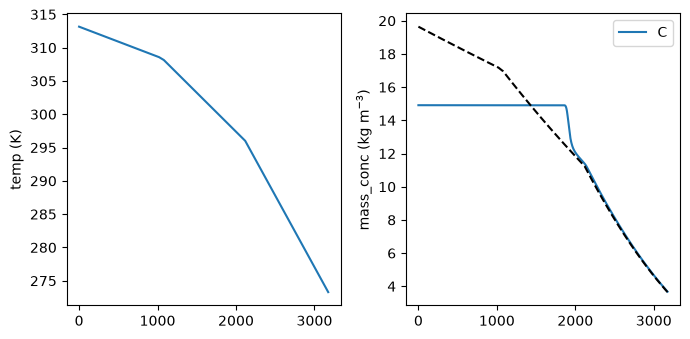

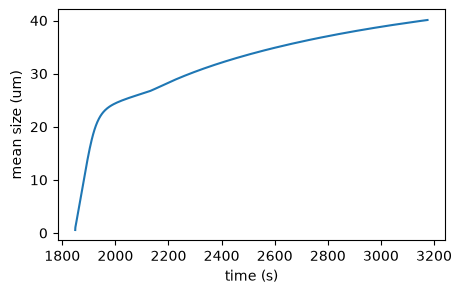

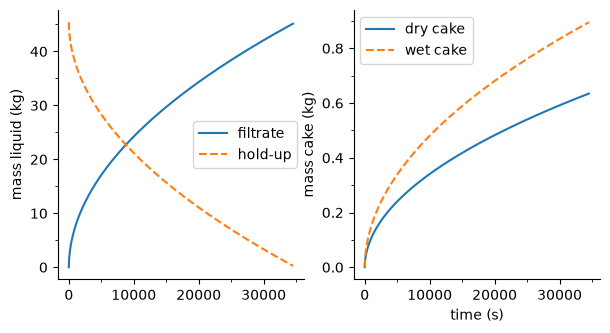

In [19]:
import matplotlib.pyplot as plt
from PharmaPy.Plotting import plot_function

fi, ax = plot_function(sim_opt.CR01, state_names=['temp', ('mass_conc', ('C', ))], figsize=(7, 3.5),
                        ncols=2)
ax[1].plot(sim_opt.CR01.result.time, sim_opt.CR01.result.solubility, '--k')
fi.tight_layout()

# Mean size constraint: CR01
moms = sim_opt.CR01.result.mu_n  # [m**n], total-population moments n=0, 1, ...
mean_size_m = np.divide(  # [m], undefined when the particle count is zero
    moms[:, 1], moms[:, 0], out=np.full_like(moms[:, 0], np.nan),
    where=moms[:, 0] > 0,
)
mean_size_profile = mean_size_m * 1e6  # [um], exact conversion from m

fig, axis = plt.subplots(figsize=(5, 3))
axis.plot(sim_opt.CR01.result.time, mean_size_profile)
axis.set_xlabel('time (s)')
axis.set_ylabel('mean size (um)')

# Production constraint: F01
sim_opt.F01.plot_profiles(figsize=(7, 3.5))